# Chapter 13: Diagram Techniques

**Source span.** Perspectives on Projective Geometry, Chapter 13, Sections 13.1-13.9, printed pages 227-246 / PDF pages 249-268.

**Chapter goal.** Turn tensor notation into a projective-geometry drawing language. Points, lines, matrices, transformations, quadratic forms, delta tensors, and epsilon tensors become typed nodes and wires whose contractions can be checked by computation.

The chapter's core move is simple but powerful: an index contraction is a wire. Once that rule is visible, rowness, columnness, left multiplication, right multiplication, and transposes become secondary bookkeeping. The important question is which pointlike and linelike slots are connected.

This notebook follows the source chapter by building a diagram calculus in six passes:

1. Translate points, lines, transformations, and quadratic forms into tensors with typed slots.
2. Read a tensor diagram as an executable contraction pattern.
3. Use transformation halos to see why internal `T` and `T^{-1}` pairs cancel.
4. Treat the delta tensor as the invisible identity wire.
5. Use the epsilon tensor for joins, meets, determinants, and orientation signs.
6. Apply the epsilon-delta rewrite to reduce closed configuration diagrams to bracket and incidence factors.

The explanations, code, diagrams, and checks are original. The source pages determine coverage and terminology, but no textbook figure, screenshot, page crop, or long passage is reused.


In [ ]:
from pathlib import Path
import sys

START = Path.cwd().resolve()
BOOK_ROOT = None
for candidate in [START, *START.parents]:
    if (candidate / "AGENTS.md").exists() and (candidate / "Perspectives on Projective Geometry.pdf").exists():
        BOOK_ROOT = candidate
        break
if BOOK_ROOT is None:
    raise RuntimeError("Could not discover the course root")
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

ARTIFACT_ROOT = BOOK_ROOT / "artifacts" / "chapter-13-diagram-techniques"
for child in ("figures", "html", "tables", "checks"):
    (ARTIFACT_ROOT / child).mkdir(parents=True, exist_ok=True)
ARTIFACT_ROOT.relative_to(BOOK_ROOT).as_posix()


In [2]:
import itertools

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import plotly.graph_objects as go
import sympy as sp
from matplotlib.patches import Circle, FancyArrowPatch, FancyBboxPatch
from PIL import Image

from utils.artifacts import artifact_path, assert_artifacts, book_relative, display_artifact, save_json, save_table

plt.rcParams.update({"figure.dpi": 140, "savefig.dpi": 170, "font.size": 10})

artifact_paths = {}
display_paths = []
numeric_checks = {}
symbolic_checks = {}

def remember(key, path, display=True):
    artifact_paths[key] = Path(path)
    if display:
        display_paths.append(Path(path))
    return Path(path)

def save_fig(fig, key, filename, display=True):
    path = artifact_path(ARTIFACT_ROOT, "figures", filename)
    fig.savefig(path, bbox_inches="tight", facecolor="white")
    plt.close(fig)
    return remember(key, path, display)

def eps3():
    eps = np.zeros((3, 3, 3), dtype=int)
    for perm in itertools.permutations(range(3)):
        inv = sum(perm[i] > perm[j] for i in range(3) for j in range(i + 1, 3))
        eps[perm] = -1 if inv % 2 else 1
    return eps

def bracket_np(a, b, c):
    return float(np.linalg.det(np.column_stack([a, b, c])))

def bracket_sp(a, b, c):
    return sp.Matrix.hstack(a, b, c).det()

def incidence_np(point, line):
    return float(np.dot(point, line))

def incidence_sp(point, line):
    return sp.Matrix(point).dot(sp.Matrix(line))

def affine(point):
    point = np.asarray(point, dtype=float)
    return point[:2] / point[2]

def cross_ratio_1d(a, b, c, d):
    return ((a - c) * (b - d)) / ((a - d) * (b - c))

def image_summary(path):
    image = Image.open(path).convert("RGB")
    arr = np.asarray(image, dtype=float)
    return {
        "path": book_relative(path),
        "width": int(image.width),
        "height": int(image.height),
        "file_size": int(Path(path).stat().st_size),
        "pixel_std": float(arr.std()),
    }

def node(ax, xy, text, color="#f8fafc", edge="#1f2937", r=0.18, fs=10):
    ax.add_patch(Circle(xy, r, facecolor=color, edgecolor=edge, lw=1.5, zorder=3))
    ax.text(*xy, text, ha="center", va="center", weight="bold", fontsize=fs, zorder=4)

def box(ax, xy, text, color="#eef2ff", edge="#334155", w=0.75, h=0.32, fs=9):
    x, y = xy
    ax.add_patch(FancyBboxPatch((x - w / 2, y - h / 2), w, h, boxstyle="round,pad=0.03",
                                 facecolor=color, edgecolor=edge, lw=1.3, zorder=3))
    ax.text(x, y, text, ha="center", va="center", fontsize=fs, weight="bold", zorder=4)

def arrow(ax, a, b, color="#334155", lw=2.0, rad=0.0):
    ax.add_patch(FancyArrowPatch(a, b, arrowstyle="-|>", mutation_scale=12, lw=lw, color=color,
                                 connectionstyle=f"arc3,rad={rad}", zorder=2))

def label(ax, xy, text, fs=9, color="#111827", ha="center"):
    ax.text(xy[0], xy[1], text, fontsize=fs, color=color, ha=ha, va="center")

def clean(ax, xlim=(0, 10), ylim=(0, 5)):
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_aspect("equal")
    ax.axis("off")


## Visualization Storyboard And Library Routing

The planner pass routes each major chapter concept to an inspectable representation:

| Concept | Representation | Library choice | Validation target |
| --- | --- | --- | --- |
| Points, lines, matrices as tensors | typed slot legend and translation table | Matplotlib plus CSV | shapes and slot patterns are recorded |
| Tensor diagrams and transformations | wire cancellation diagram | Matplotlib and NumPy | `p A q` is unchanged after transforming all objects |
| Delta tensor | identity-wire diagram | Matplotlib, NumPy, SymPy | delta contraction relabels vectors exactly |
| Epsilon tensor | join/determinant orientation visual | Matplotlib and NumPy | epsilon equals cross product and determinant contraction |
| Epsilon-delta rewrite | signed rewrite panel and bracket table | SymPy plus Matplotlib | identity holds over all visible indices; meet formula is exact |
| Configuration invariant | closed diagram reduction and proof graph | NetworkX, SymPy | expression scales by `det(T)` under projective transformation |
| Transformation lab | interactive determinant scaling | Plotly | every slider frame has near-zero determinant-scaling residual |

Static diagrams are saved as PNG because labels and arrow directions matter. The final transformation lab is HTML because the learner should vary the projective matrix and inspect the determinant scale rather than trust a single frame.


In [3]:
storyboard = {
    "chapter goal": "Use tensor diagrams as executable projective algebra.",
    "source span read": "Printed pp. 227-246 / PDF pp. 249-268, Sections 13.1-13.9.",
    "concept inventory": [
        "points and lines as grade-1 tensors with opposite slot variance",
        "transformations and quadratic forms as grade-2 tensors",
        "tensor diagrams as directed contraction graphs",
        "transformation halos and T/T^{-1} cancellation",
        "delta tensors as identity wires",
        "epsilon tensors as joins, meets, determinants, and orientation signs",
        "epsilon-delta rewrites as signed diagram simplification",
        "closed configuration diagrams as relative projective invariants",
    ],
    "visual sequence": [
        "figures/tensor-object-translation.png",
        "figures/contraction-wire-cancellation.png",
        "figures/delta-wire-identity.png",
        "figures/epsilon-join-meet-orientation.png",
        "figures/epsilon-delta-rewrite-to-brackets.png",
        "figures/configuration-invariant-reduction.png",
        "html/projective-determinant-scaling-lab.html",
    ],
    "computational checks": [
        "delta contraction identity",
        "epsilon join and determinant identities",
        "epsilon-delta identity over all index choices",
        "meet-of-joins bracket formula",
        "configuration relative invariance",
        "artifact existence and nonblank PNG checks",
    ],
    "proof-visualization strategy": "wire cancellation, signed epsilon-delta rewrite, and proof dependency graph",
    "acceptance criteria": ["nbclient executes", "no generic route-map scaffold", "scoped audits pass"],
}
remember("storyboard", save_json(storyboard, ARTIFACT_ROOT, "checks", "storyboard.json"), display=False)
book_relative(artifact_paths["storyboard"])


'artifacts/chapter-13-diagram-techniques/checks/storyboard.json'

## 1. Tensor Slots Replace Rows And Columns

In the projective plane, a point and a line are both arrays of three numbers. Their geometric roles differ because their slots have opposite variance: a point slot is outgoing and a line slot is incoming. Connecting those slots gives the scalar incidence test. A transformation has one incoming and one outgoing slot. A quadratic form has two incoming slots because it accepts two point inputs.

The figure below is the diagram alphabet for the chapter. It is paired with a CSV table so the visual terms can be audited as data.


In [4]:
eps = eps3()
delta = np.eye(3, dtype=int)
p = np.array([1.20, -0.45, 1.00])
q = np.array([-0.35, 1.10, 1.00])
r = np.array([0.80, 0.85, 1.00])
line_pq = np.cross(p, q)
A = np.array([[1.4, 0.25, -0.18], [0.25, 0.9, 0.32], [-0.18, 0.32, -1.0]])
T = np.array([[1.15, 0.30, 0.42], [-0.20, 0.95, 0.15], [0.10, -0.16, 1.00]])
Tinv = np.linalg.inv(T)

rows = [
    {"object": "point p", "grade": 1, "shape": "(3,)", "slot pattern": "one lower / outgoing", "diagram test": "connect to line"},
    {"object": "line l", "grade": 1, "shape": "(3,)", "slot pattern": "one upper / incoming", "diagram test": "connect to point"},
    {"object": "transformation T", "grade": 2, "shape": "(3, 3)", "slot pattern": "one in, one out", "diagram test": "point maps to point"},
    {"object": "quadratic form A", "grade": 2, "shape": "(3, 3)", "slot pattern": "two incoming slots", "diagram test": "two points give scalar"},
    {"object": "delta", "grade": 2, "shape": "(3, 3)", "slot pattern": "identity pair", "diagram test": "relabel an index"},
    {"object": "epsilon", "grade": 3, "shape": "(3, 3, 3)", "slot pattern": "three same-variance slots", "diagram test": "join, meet, determinant"},
]
table = remember("tensor_slot_translation_table", save_table(rows, ARTIFACT_ROOT, "tables", "tensor-slot-translation-guide.csv"))

fig, ax = plt.subplots(figsize=(10, 4.2))
clean(ax, (-0.2, 10.2), (0, 4.2))
ax.set_title("Objects are classified by tensor slots")
for x, name, color in [(0.9, "p", "#dbeafe"), (2.2, "l", "#dcfce7"), (3.7, "T", "#fef3c7"),
                       (5.2, "A", "#fee2e2"), (6.9, "delta", "#ede9fe"), (8.8, "eps", "#cffafe")]:
    if name == "delta":
        arrow(ax, (x - 0.55, 2.8), (x + 0.55, 2.8), "#6d28d9", 2.5)
        label(ax, (x, 3.25), "identity wire", 8, "#4c1d95")
    elif name == "eps":
        node(ax, (x, 2.8), "eps", color, "#0f766e", 0.25, 8)
        arrow(ax, (x - 0.75, 3.35), (x - 0.22, 2.95), "#0f766e")
        arrow(ax, (x - 0.75, 2.25), (x - 0.22, 2.65), "#0f766e")
        arrow(ax, (x + 0.24, 2.8), (x + 0.82, 2.8), "#0f766e")
        label(ax, (x, 3.65), "antisymmetric 3-node", 8, "#134e4a")
    else:
        node(ax, (x, 2.8), name, color)
arrow(ax, (1.1, 2.8), (1.78, 2.8), "#1d4ed8")
arrow(ax, (1.82, 2.8), (2.03, 2.8), "#15803d")
arrow(ax, (3.25, 2.8), (3.52, 2.8), "#92400e")
arrow(ax, (3.88, 2.8), (4.28, 2.8), "#92400e")
arrow(ax, (4.75, 3.10), (5.0, 2.93), "#991b1b")
arrow(ax, (4.75, 2.50), (5.0, 2.67), "#991b1b")
for y, expr, meaning in [
    (1.35, "p_i l^i", "closed scalar: incidence"),
    (1.05, "T^j_i p_i", "free point slot: transformed point"),
    (0.75, "A^{ij} p_i q_j", "closed scalar: conic or polar pairing"),
    (0.45, "eps_{ijk} p_i q_j", "free line slot: join"),
]:
    label(ax, (0.4, y), expr, 9, "#0f172a", "left")
    label(ax, (3.1, y), meaning, 9, "#475569", "left")
save_fig(fig, "tensor_object_translation", "tensor-object-translation.png")
{"figure": book_relative(artifact_paths["tensor_object_translation"]), "table": book_relative(table)}


{'figure': 'artifacts/chapter-13-diagram-techniques/figures/tensor-object-translation.png',
 'table': 'artifacts/chapter-13-diagram-techniques/tables/tensor-slot-translation-guide.csv'}

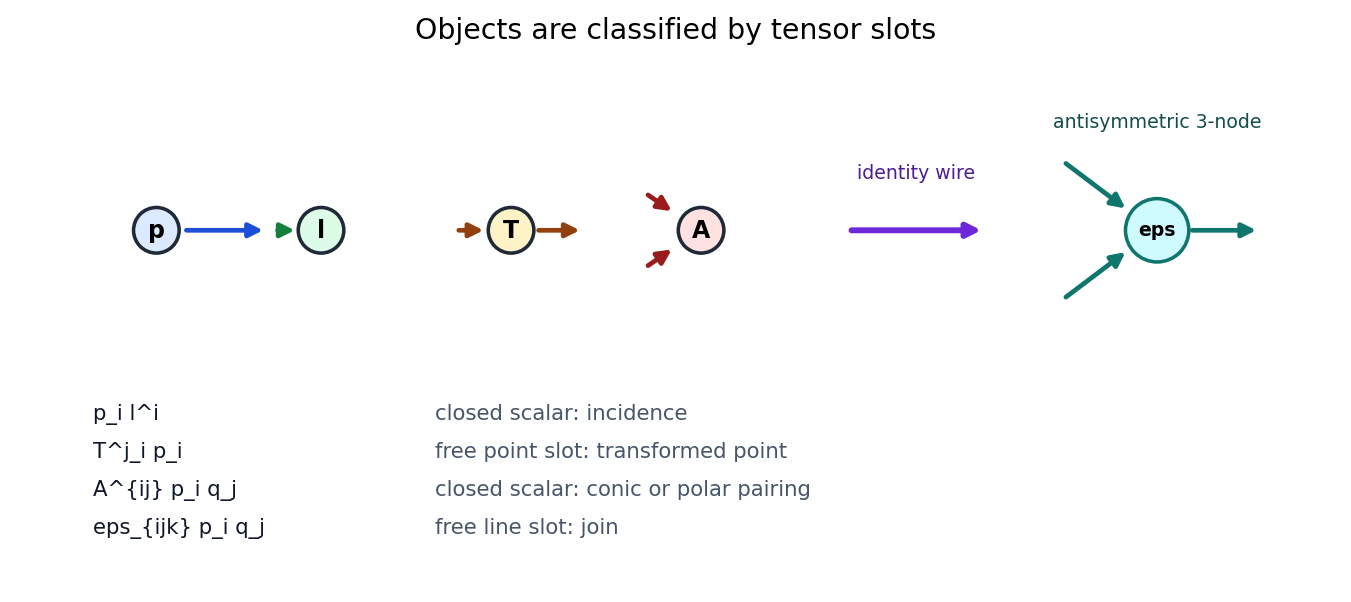

In [5]:
display_artifact(artifact_paths["tensor_object_translation"], width=900)
display_artifact(artifact_paths["tensor_slot_translation_table"])


## 2. Transformation Halos And The Delta Wire

Under a projective matrix `T`, points transform by `T` while lines transform by `T^{-T}`. In the diagram language this says: attach `T` to an outgoing pointlike slot and attach `T^{-1}` to an incoming linelike slot. On an internal wire these neighboring factors cancel, leaving the delta tensor, which is just the identity wire.

The first figure checks a bilinear conic/polar pairing. The second isolates the delta tensor as a relabeling operation.


In [6]:
base_pairing = float(np.einsum("i,ij,j->", p, A, q))
pt, qt = T @ p, T @ q
At = Tinv.T @ A @ Tinv
transformed_pairing = float(np.einsum("i,ij,j->", pt, At, qt))
numeric_checks["polar_pairing_invariance_error"] = abs(base_pairing - transformed_pairing)
line_t = Tinv.T @ line_pq
numeric_checks["transformed_line_incidence_max"] = max(abs(incidence_np(pt, line_t)), abs(incidence_np(qt, line_t)))

fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(10.5, 5.2))
for ax in (ax0, ax1):
    clean(ax, (0, 10), (0, 2.4))
ax0.set_title("Closed pairing p A q")
for x, txt, col in [(2.0, "p", "#dbeafe"), (5.0, "A", "#fee2e2"), (8.0, "q", "#dbeafe")]:
    node(ax0, (x, 1.2), txt, col)
arrow(ax0, (2.25, 1.2), (4.78, 1.2))
arrow(ax0, (7.75, 1.2), (5.22, 1.2))
label(ax0, (5.0, 0.55), f"value = {base_pairing:.6f}")
ax1.set_title("After transforming objects, internal halos cancel")
xs = [(0.9, "p"), (2.2, "T"), (3.7, "T^{-1}"), (5.0, "A"), (6.3, "T^{-1}"), (7.8, "T"), (9.1, "q")]
for x, txt in xs:
    box(ax1, (x, 1.2), txt, "#fef3c7" if "T" in txt else "#dbeafe")
for (x0, _), (x1, _) in zip(xs[:-1], xs[1:]):
    arrow(ax1, (x0 + 0.35, 1.2), (x1 - 0.35, 1.2))
for x in (2.95, 7.05):
    label(ax1, (x, 1.85), "T / T^{-1} -> delta", 8, "#991b1b")
    ax1.plot([x - 0.55, x + 0.55], [1.65, 1.65], color="#dc2626", lw=2)
label(ax1, (5.0, 0.45), f"transformed value = {transformed_pairing:.6f}; residual = {numeric_checks['polar_pairing_invariance_error']:.2e}")
save_fig(fig, "contraction_wire_cancellation", "contraction-wire-cancellation.png")

delta_p = np.einsum("ij,j->i", delta, p)
delta_line = np.einsum("i,ij->j", line_pq, delta)
numeric_checks["delta_point_relabel_error"] = float(np.max(np.abs(delta_p - p)))
numeric_checks["delta_line_relabel_error"] = float(np.max(np.abs(delta_line - line_pq)))
x0, x1, x2 = sp.symbols("x0 x1 x2")
symbolic_checks["delta_relabels_vector"] = bool(sp.eye(3) * sp.Matrix([x0, x1, x2]) == sp.Matrix([x0, x1, x2]))

fig, ax = plt.subplots(figsize=(8.8, 3.0))
clean(ax, (0, 9), (0, 3))
ax.set_title("Delta tensor disappears into an identity wire")
arrow(ax, (0.8, 1.5), (2.35, 1.5), "#6d28d9", 2.3)
node(ax, (2.65, 1.5), "delta", "#ede9fe", "#6d28d9", 0.30, 8)
arrow(ax, (2.95, 1.5), (4.5, 1.5), "#6d28d9", 2.3)
label(ax, (2.65, 0.9), "delta^i_j", 9, "#4c1d95")
arrow(ax, (5.35, 1.5), (8.15, 1.5), "#334155", 2.6)
label(ax, (6.75, 2.05), "same wire after relabeling", 10)
label(ax, (0.8, 2.25), "p_j", 10, "#1d4ed8")
label(ax, (4.45, 2.25), "p_i", 10, "#1d4ed8")
label(ax, (0.9, 0.4), f"point residual {numeric_checks['delta_point_relabel_error']:.1e}", 9, "#475569", "left")
save_fig(fig, "delta_wire_identity", "delta-wire-identity.png")

{key: numeric_checks[key] for key in ["polar_pairing_invariance_error", "transformed_line_incidence_max", "delta_point_relabel_error"]}


{'polar_pairing_invariance_error': 0.0,
 'transformed_line_incidence_max': 2.220446049250313e-16,
 'delta_point_relabel_error': 0.0}

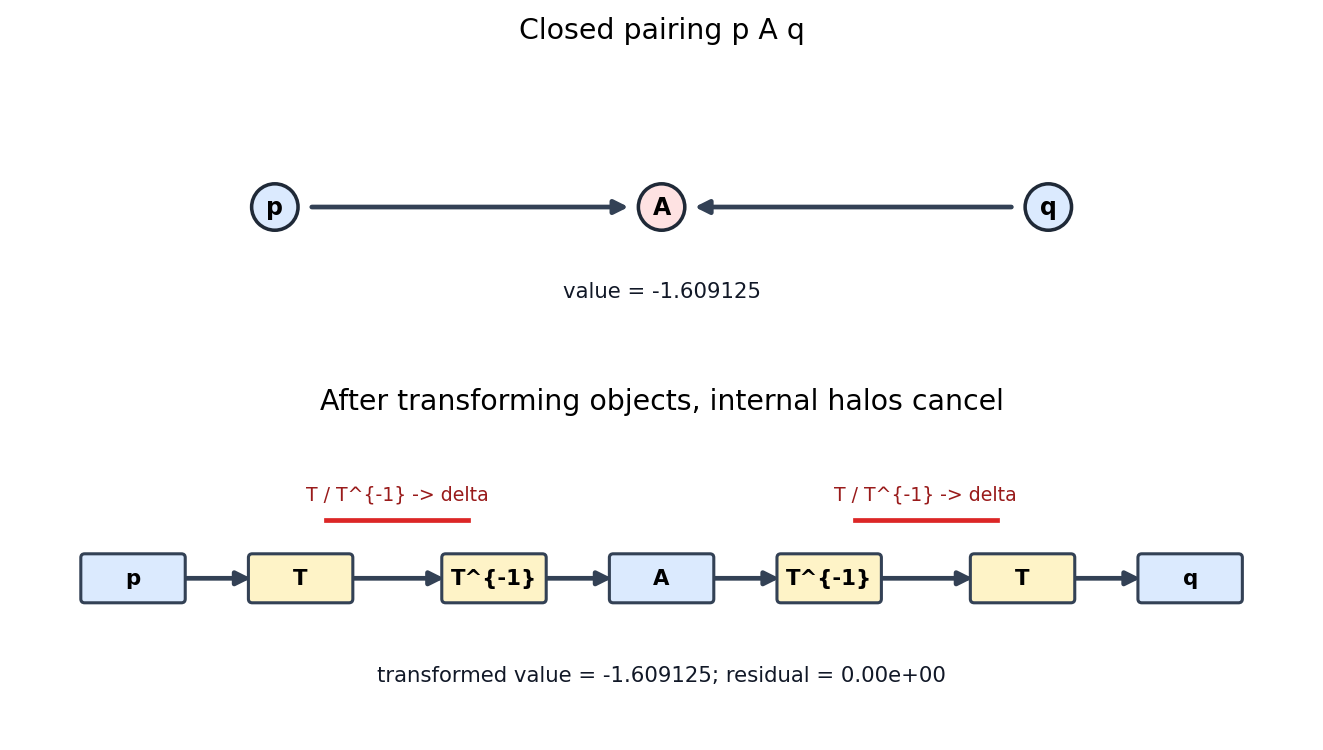

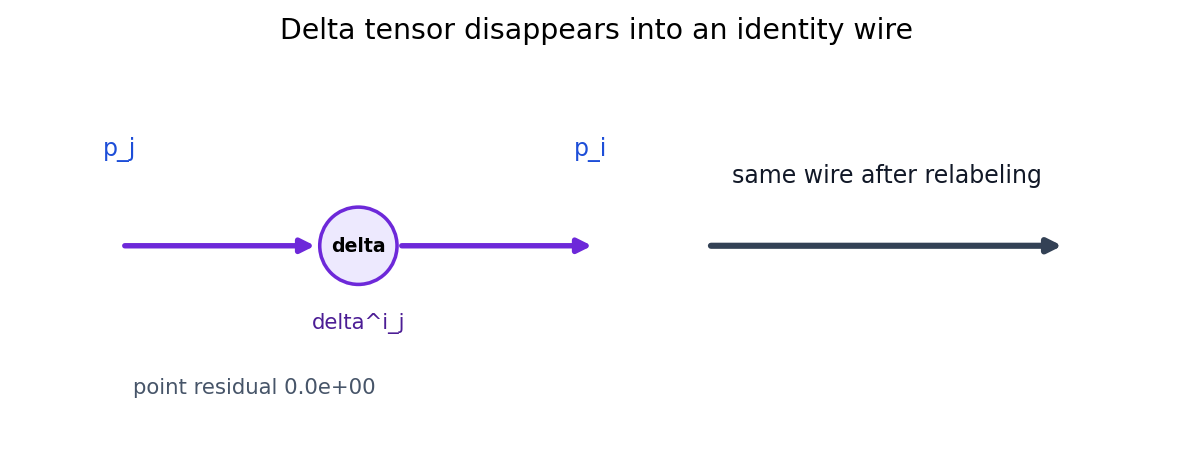

In [7]:
display_artifact(artifact_paths["contraction_wire_cancellation"], width=900)
display_artifact(artifact_paths["delta_wire_identity"], width=850)


## 3. Epsilon Tensors: Joins, Meets, Determinants

The rank-3 epsilon tensor is completely antisymmetric. In the projective plane this single tensor encodes several familiar constructions. Two point inputs leave a linelike output, which is exactly the join line. Three point inputs produce the determinant bracket, so the result vanishes exactly in the collinear case. Swapping two input slots reverses the sign.


In [8]:
join_eps = np.einsum("ijk,i,j->k", eps, p, q)
det_eps = float(np.einsum("ijk,i,j,k->", eps, p, q, r))
det_swap = float(np.einsum("ijk,j,i,k->", eps, p, q, r))
numeric_checks["epsilon_join_cross_error"] = float(np.max(np.abs(join_eps - np.cross(p, q))))
numeric_checks["epsilon_determinant_error"] = abs(det_eps - bracket_np(p, q, r))
numeric_checks["epsilon_swap_sum_error"] = abs(det_eps + det_swap)
numeric_checks["join_incidence_max"] = max(abs(incidence_np(p, join_eps)), abs(incidence_np(q, join_eps)))

P, Q, R = affine(p), affine(q), affine(r)
xs = np.linspace(-1.0, 1.8, 100)
ys = -(join_eps[0] * xs + join_eps[2]) / join_eps[1]
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10.8, 4.2))
ax0.set_title("Two point inputs to epsilon leave a line")
ax0.plot(xs, ys, color="#0f766e", lw=2, label="join from epsilon")
ax0.scatter([P[0], Q[0], R[0]], [P[1], Q[1], R[1]], s=55, color=["#1d4ed8", "#1d4ed8", "#dc2626"])
for name, xy in [("p", P), ("q", Q), ("r", R)]:
    ax0.text(xy[0] + 0.04, xy[1] + 0.04, name, weight="bold")
ax0.set_aspect("equal", adjustable="box")
ax0.grid(True, color="#e5e7eb")
ax0.legend()
ax0.set_xlabel("x/z")
ax0.set_ylabel("y/z")
clean(ax1, (0, 6.7), (0, 4.0))
ax1.set_title("Swapping two epsilon slots changes sign")
node(ax1, (3.0, 2.0), "eps", "#cffafe", "#0f766e", 0.32, 8)
for xy, name in [((1.3, 3.1), "p"), ((1.3, 0.9), "q"), ((5.0, 2.0), "r")]:
    node(ax1, xy, name, "#dbeafe")
arrow(ax1, (1.55, 3.0), (2.72, 2.25), "#0f766e")
arrow(ax1, (1.55, 1.0), (2.72, 1.75), "#0f766e")
arrow(ax1, (3.32, 2.0), (4.75, 2.0), "#0f766e")
label(ax1, (0.35, 0.35), f"eps(p,q,r) = {det_eps:.6f}", 9, "#0f172a", "left")
label(ax1, (3.6, 0.35), f"eps(q,p,r) = {det_swap:.6f}", 9, "#0f172a", "left")
save_fig(fig, "epsilon_join_meet_orientation", "epsilon-join-meet-orientation.png")
{k: numeric_checks[k] for k in ["epsilon_join_cross_error", "epsilon_determinant_error", "epsilon_swap_sum_error", "join_incidence_max"]}


{'epsilon_join_cross_error': 0.0,
 'epsilon_determinant_error': 0.0,
 'epsilon_swap_sum_error': 2.220446049250313e-16,
 'join_incidence_max': 2.220446049250313e-16}

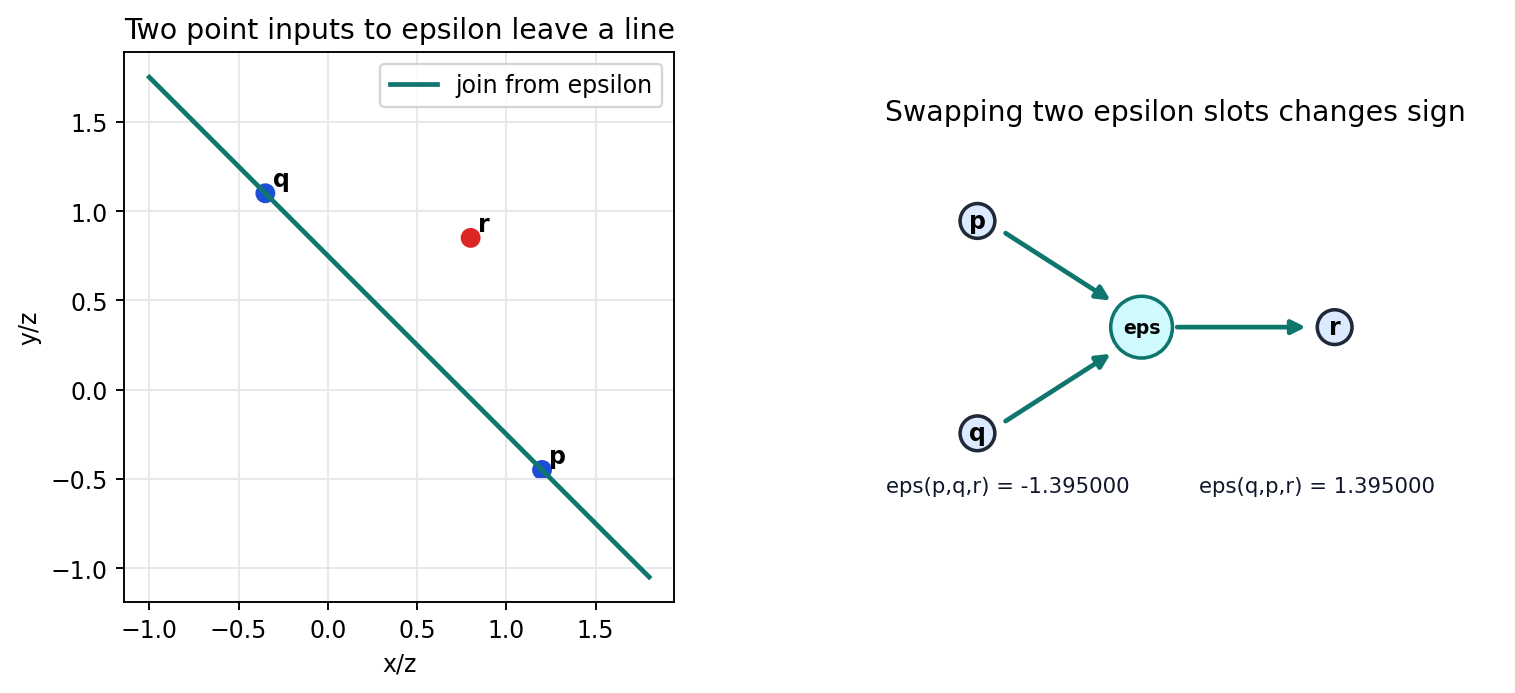

In [9]:
display_artifact(artifact_paths["epsilon_join_meet_orientation"], width=900)


## 4. The Epsilon-Delta Rewrite

The key simplification rule contracts one slot of a covariant epsilon tensor with one slot of a contravariant epsilon tensor:

$$
\sum_k \epsilon_{ijk}\epsilon_{lmk}
=
\delta_{il}\delta_{jm} - \delta_{im}\delta_{jl}.
$$

The minus sign is not optional. It is the record of the crossed pairing of the remaining slots. Applying this rule to two joined point-pairs gives a bracket expression for their meet:

$$
(a \times b) \times (c \times d)
=
[a,c,d] b - [b,c,d] a
=
[a,b,d] c - [a,b,c] d.
$$


In [10]:
for i, j, l, m in itertools.product(range(3), repeat=4):
    lhs = sum(sp.LeviCivita(i, j, k) * sp.LeviCivita(l, m, k) for k in range(3))
    rhs = sp.KroneckerDelta(i, l) * sp.KroneckerDelta(j, m) - sp.KroneckerDelta(i, m) * sp.KroneckerDelta(j, l)
    assert sp.simplify(lhs - rhs) == 0
symbolic_checks["epsilon_delta_identity"] = True

syms = sp.symbols("a0:3 b0:3 c0:3 d0:3")
a, b, c, d = (sp.Matrix(syms[i:i+3]) for i in range(0, 12, 3))
meet = a.cross(b).cross(c.cross(d))
split1 = bracket_sp(a, c, d) * b - bracket_sp(b, c, d) * a
split2 = bracket_sp(a, b, d) * c - bracket_sp(a, b, c) * d
assert all(sp.simplify(meet[i] - split1[i]) == 0 for i in range(3))
assert all(sp.simplify(split1[i] - split2[i]) == 0 for i in range(3))
symbolic_checks["meet_of_joins_bracket_formula"] = True
symbolic_checks["two_cramer_splits_agree"] = True

rewrite_rows = [
    {"diagram piece": "epsilon-epsilon connection", "index form": "sum_k eps_ijk eps_lmk", "meaning": "one internal epsilon wire"},
    {"diagram piece": "parallel delta pairing", "index form": "delta_il delta_jm", "meaning": "first surviving pairing"},
    {"diagram piece": "crossed delta pairing", "index form": "- delta_im delta_jl", "meaning": "antisymmetric second pairing"},
    {"diagram piece": "meet of joins", "index form": "(a x b) x (c x d)", "meaning": "intersection point"},
    {"diagram piece": "bracket split", "index form": "[a c d] b - [b c d] a", "meaning": "same point on line ab"},
]
rewrite_table = remember("epsilon_delta_rewrite_terms", save_table(rewrite_rows, ARTIFACT_ROOT, "tables", "epsilon-delta-rewrite-terms.csv"))

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11.5, 4.3))
for ax in (ax0, ax1):
    clean(ax, (0, 8), (0, 4.1))
ax0.set_title("Epsilon-epsilon wire becomes two delta pairings")
node(ax0, (2.3, 2.2), "eps", "#cffafe", "#0f766e", 0.27, 8)
node(ax0, (4.1, 2.2), "eps", "#cffafe", "#0f766e", 0.27, 8)
arrow(ax0, (2.58, 2.2), (3.82, 2.2), "#0f766e", 2.4)
for xy, text in [((1.0, 3.25), "i"), ((1.0, 1.15), "j"), ((5.45, 3.25), "l"), ((5.45, 1.15), "m")]:
    label(ax0, xy, text, 11)
arrow(ax0, (1.25, 3.15), (2.05, 2.42))
arrow(ax0, (1.25, 1.25), (2.05, 1.98))
arrow(ax0, (4.35, 2.42), (5.15, 3.15))
arrow(ax0, (4.35, 1.98), (5.15, 1.25))
label(ax0, (3.2, 0.55), "= delta_il delta_jm - delta_im delta_jl", 10)
ax1.set_title("Meet of joined point-pairs")
for xy, name in [((1.0, 3.15), "a"), ((1.0, 1.05), "b"), ((6.8, 3.15), "c"), ((6.8, 1.05), "d")]:
    node(ax1, xy, name, "#dbeafe")
node(ax1, (2.55, 2.1), "eps", "#cffafe", "#0f766e", 0.24, 8)
node(ax1, (5.25, 2.1), "eps", "#cffafe", "#0f766e", 0.24, 8)
for start, end in [((1.22, 3.05), (2.35, 2.32)), ((1.22, 1.15), (2.35, 1.90)),
                   ((6.58, 3.05), (5.45, 2.32)), ((6.58, 1.15), (5.45, 1.90)),
                   ((2.82, 2.1), (4.98, 2.1))]:
    arrow(ax1, start, end, "#0f766e", 2.0)
label(ax1, (0.45, 0.35), "(a x b) x (c x d) = [a c d] b - [b c d] a", 9, "#0f172a", "left")
save_fig(fig, "epsilon_delta_rewrite_to_brackets", "epsilon-delta-rewrite-to-brackets.png")
{"epsilon_delta_identity": True, "meet_formula": True, "table": book_relative(rewrite_table)}


{'epsilon_delta_identity': True,
 'meet_formula': True,
 'table': 'artifacts/chapter-13-diagram-techniques/tables/epsilon-delta-rewrite-terms.csv'}

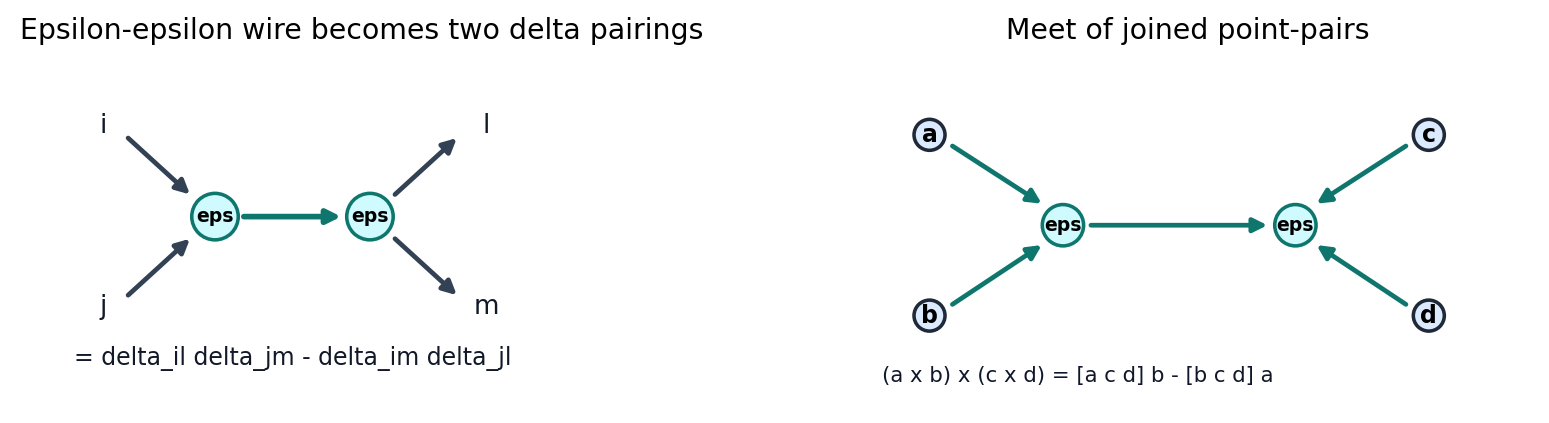

In [11]:
display_artifact(artifact_paths["epsilon_delta_rewrite_to_brackets"], width=920)
display_artifact(artifact_paths["epsilon_delta_rewrite_terms"])


## 5. Transformation Lab And Configuration Invariant

An epsilon bracket scales predictably. If three point inputs are transformed by `T`, then `[Tp,Tq,Tr] = det(T)[p,q,r]`. The Plotly lab varies a projective matrix and shows that ratio frame by frame.

The final closed configuration uses the expression

$$
I(p,q,r,s,l) = [r,q,s]\langle p,l\rangle - [r,p,s]\langle q,l\rangle.
$$

The determinant factors scale by `det(T)`. The point-line incidence factors do not change when the line is transformed dually. Therefore the whole expression is a relative invariant of weight one. The NetworkX panel records the proof dependencies that make this reduction legal.


In [12]:
base = {"p": np.array([-0.85, -0.55, 1.0]), "q": np.array([0.95, -0.30, 1.0]), "r": np.array([0.10, 0.95, 1.0])}
base_bracket = bracket_np(base["p"], base["q"], base["r"])
params = np.linspace(-0.65, 0.65, 11)
frames, first, max_err = [], None, 0.0
base_xy = np.array([affine(base[k]) for k in ["p", "q", "r", "p"]])
for tau in params:
    Ttau = np.array([[1.0 + 0.08 * tau, 0.35 * tau, 0.18], [-0.18, 1.0 - 0.06 * tau, -0.12 * tau], [0.10 * tau, -0.16, 1.0]])
    tr = {k: Ttau @ v for k, v in base.items()}
    tr_xy = np.array([affine(tr[k]) for k in ["p", "q", "r", "p"]])
    ratio = bracket_np(tr["p"], tr["q"], tr["r"]) / base_bracket
    det = float(np.linalg.det(Ttau))
    max_err = max(max_err, abs(ratio - det))
    text = f"tau={tau:+.2f}<br>ratio={ratio:.6f}<br>det(T)={det:.6f}<br>residual={abs(ratio-det):.1e}"
    data = [
        go.Scatter(x=base_xy[:, 0], y=base_xy[:, 1], mode="lines+markers+text", text=["p", "q", "r", "p"], name="base", line=dict(color="#94a3b8", width=2)),
        go.Scatter(x=tr_xy[:, 0], y=tr_xy[:, 1], mode="lines+markers+text", text=["Tp", "Tq", "Tr", "Tp"], name="transformed", line=dict(color="#0f766e", width=3)),
        go.Scatter(x=[-1.55], y=[1.30], mode="text", text=[text], showlegend=False),
    ]
    first = data if first is None else first
    frames.append(go.Frame(data=data, name=f"{tau:.2f}"))
fig = go.Figure(data=first, frames=frames)
fig.update_layout(
    title="Epsilon determinant scaling under projective transformations",
    width=860, height=540,
    xaxis=dict(scaleanchor="y", range=[-1.8, 1.8], gridcolor="#e5e7eb"),
    yaxis=dict(range=[-1.25, 1.55], gridcolor="#e5e7eb"),
    sliders=[{"steps": [{"args": [[f"{tau:.2f}"], {"frame": {"duration": 0, "redraw": True}, "mode": "immediate"}], "label": f"{tau:.2f}", "method": "animate"} for tau in params]}],
)
lab = artifact_path(ARTIFACT_ROOT, "html", "projective-determinant-scaling-lab.html")
fig.write_html(lab, include_plotlyjs=True)
remember("projective_determinant_scaling_lab", lab)
numeric_checks["plotly_lab_max_det_scaling_error"] = float(max_err)

pS = sp.Matrix([1, 0, 1])
qS = sp.Matrix([0, 1, 1])
rS = sp.Matrix([2, -1, 1])
sS = sp.Matrix([-1, 2, 1])
lS = sp.Matrix([2, -3, 1])
TS = sp.Matrix([[2, 1, 0], [0, 1, 1], [1, 0, 2]])
def config_expr(pv, qv, rv, sv, lv):
    return bracket_sp(rv, qv, sv) * incidence_sp(pv, lv) - bracket_sp(rv, pv, sv) * incidence_sp(qv, lv)
base_config = sp.simplify(config_expr(pS, qS, rS, sS, lS))
transformed_config = sp.simplify(config_expr(TS * pS, TS * qS, TS * rS, TS * sS, TS.inv().T * lS))
residual = sp.simplify(transformed_config - TS.det() * base_config)
assert residual == 0
symbolic_checks["configuration_relative_invariance"] = True
numeric_checks["configuration_relative_invariance_residual"] = 0.0

G = nx.DiGraph()
G.add_edges_from([
    ("closed diagram", "epsilon-delta rewrite"), ("delta wires", "epsilon-delta rewrite"),
    ("epsilon signs", "epsilon-delta rewrite"), ("epsilon-delta rewrite", "bracket factors"),
    ("point-line contractions", "incidence factors"), ("dual line transform", "incidence factors"),
    ("determinant scaling", "bracket factors"), ("bracket factors", "relative invariant"),
    ("incidence factors", "relative invariant"),
])
pos = {"closed diagram": (0.2, 3.3), "delta wires": (0.2, 2.45), "epsilon signs": (0.2, 1.6),
       "epsilon-delta rewrite": (2.7, 2.45), "point-line contractions": (2.7, 3.45),
       "dual line transform": (2.7, 0.75), "determinant scaling": (2.7, 1.35),
       "bracket factors": (5.0, 2.45), "incidence factors": (5.0, 3.35), "relative invariant": (7.0, 2.9)}
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 4.8), gridspec_kw={"width_ratios": [1.0, 1.35]})
clean(ax0, (0, 6), (0, 4.5))
clean(ax1, (-0.3, 8.0), (0.25, 3.95))
ax0.set_title("Closed configuration diagram")
for xy, name, col in [((0.8, 3.35), "p", "#dbeafe"), ((0.8, 1.15), "q", "#dbeafe"), ((2.7, 3.95), "r", "#dbeafe"), ((2.7, 0.55), "s", "#dbeafe"), ((5.0, 2.25), "l", "#dcfce7")]:
    node(ax0, xy, name, col)
for xy in [(2.2, 2.65), (3.7, 2.65), (3.0, 1.75)]:
    node(ax0, xy, "eps", "#cffafe", "#0f766e", 0.22, 8)
for a0, b0 in [((1.0, 3.25), (2.0, 2.80)), ((1.0, 1.25), (2.8, 1.82)), ((2.68, 3.75), (2.25, 2.90)), ((2.68, 0.78), (3.0, 1.55)), ((3.93, 2.65), (4.82, 2.30)), ((2.43, 2.65), (3.47, 2.65)), ((3.12, 1.92), (3.62, 2.48))]:
    arrow(ax0, a0, b0, "#0f766e")
label(ax0, (0.25, 0.22), "[r,q,s]<p,l> - [r,p,s]<q,l>", 9, "#0f172a", "left")
ax1.set_title("Proof dependency graph")
nx.draw_networkx_edges(G, pos, ax=ax1, arrows=True, arrowstyle="-|>", arrowsize=13, edge_color="#64748b", width=1.4)
for n, xy in pos.items():
    box(ax1, xy, n.replace(" ", "\n"), "#fef3c7" if n == "relative invariant" else "#f8fafc", w=1.35, h=0.46, fs=7.2)
save_fig(fig, "configuration_invariant_reduction", "configuration-invariant-reduction.png")

{"lab": book_relative(lab), "det_scaling_error": max_err, "configuration_residual": str(residual)}


{'lab': 'artifacts/chapter-13-diagram-techniques/html/projective-determinant-scaling-lab.html',
 'det_scaling_error': 3.3306690738754696e-16,
 'configuration_residual': '0'}

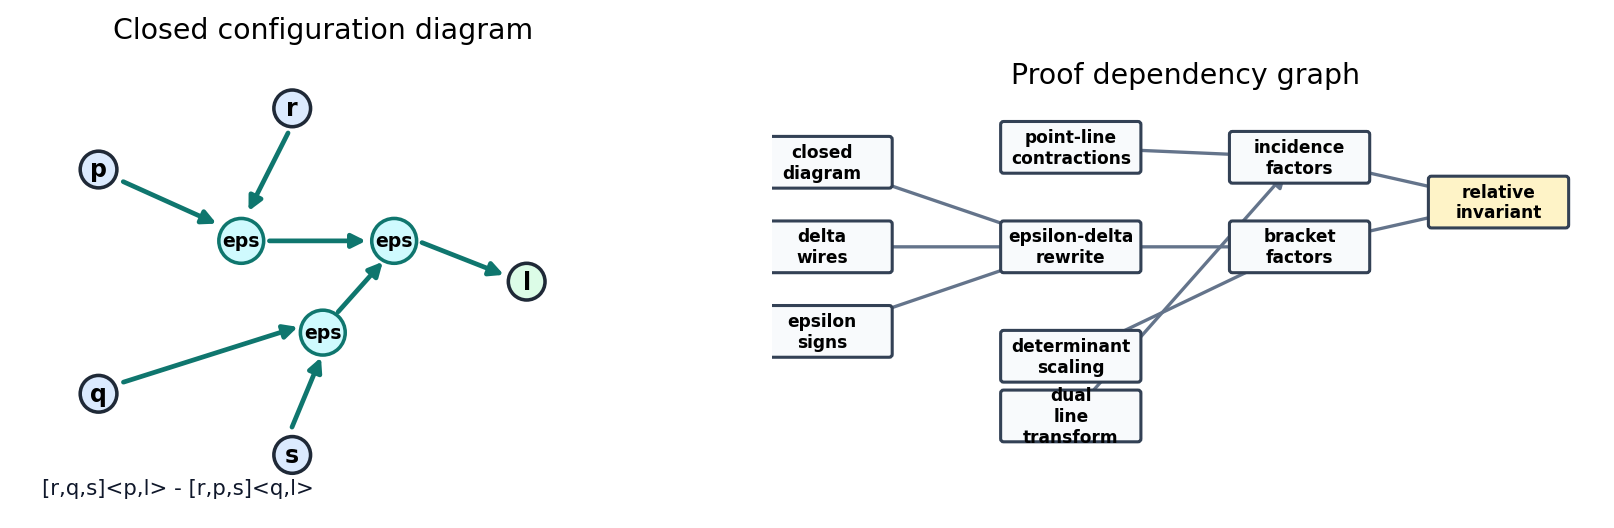

In [13]:
display_artifact(artifact_paths["projective_determinant_scaling_lab"], width="100%", height=560)
display_artifact(artifact_paths["configuration_invariant_reduction"], width=940)


## Artifact Gallery

Direct artifact links keep the notebook readable before execution.

![Tensor object translation](../../artifacts/chapter-13-diagram-techniques/figures/tensor-object-translation.png)

![Transformation wire cancellation](../../artifacts/chapter-13-diagram-techniques/figures/contraction-wire-cancellation.png)

![Delta wire identity](../../artifacts/chapter-13-diagram-techniques/figures/delta-wire-identity.png)

![Epsilon join and orientation](../../artifacts/chapter-13-diagram-techniques/figures/epsilon-join-meet-orientation.png)

![Epsilon-delta rewrite](../../artifacts/chapter-13-diagram-techniques/figures/epsilon-delta-rewrite-to-brackets.png)

![Configuration invariant reduction](../../artifacts/chapter-13-diagram-techniques/figures/configuration-invariant-reduction.png)

Open the [projective determinant scaling lab](../../artifacts/chapter-13-diagram-techniques/html/projective-determinant-scaling-lab.html), inspect the [tensor slot translation table](../../artifacts/chapter-13-diagram-techniques/tables/tensor-slot-translation-guide.csv), and compare the [epsilon-delta rewrite table](../../artifacts/chapter-13-diagram-techniques/tables/epsilon-delta-rewrite-terms.csv) with the symbolic checks.


## Applied Lab

Use the notebook as a diagram calculator. Choose four homogeneous points `a,b,c,d` whose joined lines are not equal. Compute `(a x b) x (c x d)` and both bracket-vector expansions. Then apply an invertible matrix `T` to all four points and check that the meet point transforms by `T` up to homogeneous scale.

The important practice is to attach a validation target to every diagram move. Delta wires relabel. Epsilon wires alternate. Bracket determinants scale by `det(T)`. Point-line contractions stay unchanged when the line uses the dual transform. A diagrammatic proof fails exactly when one of those local checks fails.

## Takeaways

- Tensor diagrams are typed contraction graphs.
- Points, lines, transformations, and quadratic forms are arrays with different slot patterns.
- Delta is the identity wire.
- Epsilon is the antisymmetric node that produces joins, meets, and determinant brackets.
- The epsilon-delta rule is the sign-sensitive rewrite that turns epsilon networks into bracket algebra.
- Closed point-line configuration diagrams reduce to determinants and incidence factors, with projective scaling controlled by determinant powers.


In [14]:
lab_a = np.array([1.0, -0.4, 1.0])
lab_b = np.array([-0.3, 1.2, 1.0])
lab_c = np.array([1.4, 0.7, 1.0])
lab_d = np.array([-1.1, -0.6, 1.0])
lab_T = np.array([[1.0, 0.35, -0.20], [-0.15, 1.1, 0.30], [0.08, -0.12, 1.0]])
meet_direct = np.cross(np.cross(lab_a, lab_b), np.cross(lab_c, lab_d))
meet_split_1 = bracket_np(lab_a, lab_c, lab_d) * lab_b - bracket_np(lab_b, lab_c, lab_d) * lab_a
meet_split_2 = bracket_np(lab_a, lab_b, lab_d) * lab_c - bracket_np(lab_a, lab_b, lab_c) * lab_d
meet_t = np.cross(np.cross(lab_T @ lab_a, lab_T @ lab_b), np.cross(lab_T @ lab_c, lab_T @ lab_d))
expected_t = lab_T @ meet_direct
numeric_checks["lab_meet_split_1_error"] = float(np.max(np.abs(meet_direct - meet_split_1)))
numeric_checks["lab_meet_split_2_error"] = float(np.max(np.abs(meet_direct - meet_split_2)))
numeric_checks["lab_meet_projective_transform_cross_norm"] = float(np.linalg.norm(np.cross(meet_t, expected_t)))
xs = [-1.4, -0.2, 0.75, 1.6]
ys = [(1.1 * x - 0.25) / (0.22 * x + 1.0) for x in xs]
numeric_checks["cross_ratio_error"] = float(abs(cross_ratio_1d(*xs) - cross_ratio_1d(*ys)))

required = [
    artifact_paths["tensor_object_translation"],
    artifact_paths["contraction_wire_cancellation"],
    artifact_paths["delta_wire_identity"],
    artifact_paths["epsilon_join_meet_orientation"],
    artifact_paths["epsilon_delta_rewrite_to_brackets"],
    artifact_paths["configuration_invariant_reduction"],
    artifact_paths["projective_determinant_scaling_lab"],
    artifact_paths["tensor_slot_translation_table"],
    artifact_paths["epsilon_delta_rewrite_terms"],
    artifact_paths["storyboard"],
]
assert_artifacts(required, min_size=256)
assert numeric_checks["polar_pairing_invariance_error"] < 1e-10
assert numeric_checks["transformed_line_incidence_max"] < 1e-10
assert numeric_checks["delta_point_relabel_error"] == 0.0
assert numeric_checks["epsilon_join_cross_error"] == 0.0
assert numeric_checks["epsilon_determinant_error"] < 1e-12
assert numeric_checks["epsilon_swap_sum_error"] < 1e-12
assert numeric_checks["join_incidence_max"] < 1e-12
assert numeric_checks["plotly_lab_max_det_scaling_error"] < 1e-12
assert numeric_checks["configuration_relative_invariance_residual"] == 0.0
assert numeric_checks["lab_meet_split_1_error"] < 1e-12
assert numeric_checks["lab_meet_split_2_error"] < 1e-12
assert numeric_checks["lab_meet_projective_transform_cross_norm"] < 1e-10
assert numeric_checks["cross_ratio_error"] < 1e-12
assert all(symbolic_checks.values())

png_summaries = [image_summary(p) for p in display_paths if Path(p).suffix.lower() == ".png"]
for item in png_summaries:
    assert item["width"] >= 200 and item["height"] >= 150 and item["pixel_std"] > 1.0
visual_checks = {
    "chapter": 13,
    "source_span": "printed pp. 227-246 / PDF pp. 249-268",
    "display_artifacts": [book_relative(p) for p in display_paths],
    "all_files_exist": all(Path(p).exists() and Path(p).stat().st_size > 256 for p in display_paths),
    "cross_ratio_error": numeric_checks["cross_ratio_error"],
    "numeric_checks": {k: float(v) for k, v in sorted(numeric_checks.items())},
    "symbolic_checks": {k: bool(v) for k, v in sorted(symbolic_checks.items())},
    "png_summaries": png_summaries,
}
visual_path = remember("visual_checks", save_json(visual_checks, ARTIFACT_ROOT, "checks", "visual-checks.json"), display=False)
final_sanity = {
    "chapter": 13,
    "notebook_executed": True,
    "source_span": "printed pp. 227-246 / PDF pp. 249-268",
    "storyboard_items_implemented": storyboard["visual sequence"],
    "artifacts": [book_relative(p) for p in required + [visual_path]],
    "checks": {
        "all_symbolic_checks_true": all(symbolic_checks.values()),
        "max_numeric_residual": max(abs(float(v)) for v in numeric_checks.values()),
        "png_count": len(png_summaries),
        "html_count": sum(Path(p).suffix.lower() == ".html" for p in display_paths),
        "table_count": sum(Path(p).suffix.lower() == ".csv" for p in display_paths),
    },
}
final_path = remember("final_sanity", save_json(final_sanity, ARTIFACT_ROOT, "checks", "final-sanity.json"), display=False)
assert_artifacts([visual_path, final_path], min_size=256)
final_sanity


{'chapter': 13,
 'notebook_executed': True,
 'source_span': 'printed pp. 227-246 / PDF pp. 249-268',
 'storyboard_items_implemented': ['figures/tensor-object-translation.png',
  'figures/contraction-wire-cancellation.png',
  'figures/delta-wire-identity.png',
  'figures/epsilon-join-meet-orientation.png',
  'figures/epsilon-delta-rewrite-to-brackets.png',
  'figures/configuration-invariant-reduction.png',
  'html/projective-determinant-scaling-lab.html'],
 'artifacts': ['artifacts/chapter-13-diagram-techniques/figures/tensor-object-translation.png',
  'artifacts/chapter-13-diagram-techniques/figures/contraction-wire-cancellation.png',
  'artifacts/chapter-13-diagram-techniques/figures/delta-wire-identity.png',
  'artifacts/chapter-13-diagram-techniques/figures/epsilon-join-meet-orientation.png',
  'artifacts/chapter-13-diagram-techniques/figures/epsilon-delta-rewrite-to-brackets.png',
  'artifacts/chapter-13-diagram-techniques/figures/configuration-invariant-reduction.png',
  'artifact